In [2]:
# If running for the first time, uncomment to install dependencies
!pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels xgboost tensorflow


# Comparative Experimental Analysis of Forecasting Methods
## Member 2 — Daily Minimum Temperature Dataset (Melbourne)

**Course:** Applied Statistics and Experimental Analysis

### ⚖️ A note on "fair" comparison across model families
To evaluate statistical forecasting models (Holt-Winters, ARIMA) fairly against windowed machine learning models (XGBoost) and deep learning models (LSTM, Transformer), we evaluate all of them on the exact same 20% chronological test partition ($N=730$ days).

* Holt-Winters and ARIMA are evaluated using **walk-forward validation** (making one-step-ahead forecasts and appending the true temperature to the history before the next forecast step).
* XGBoost, LSTM, and Transformer make predictions using a **sliding window of size 30 lags** ($X_t = [y_{t-30}, \dots, y_{t-1}]$).


## 1. Setup & Imports


In [3]:
import os
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

WINDOW = 30          # sliding window size (required by project spec)
TEST_RATIO = 0.20    # 80/20 split, no shuffling
DATA_PATH = "data/daily-min-temperatures.csv"

print("Setup complete. TensorFlow:", tf.__version__)


Setup complete. TensorFlow: 2.20.0


In [4]:
# from google.colab import drive
# try:
#     drive.mount('/content/drive')
# except Exception:
#     print("Google Drive mount skipped (running locally or drive already mounted).")


## 2. Load Dataset


In [5]:
# Detect if Google Drive is mounted, and adjust path if running in Colab
colab_drive_path = "/content/drive/MyDrive/Colab Notebooks/IT2022E_Project/data/daily-min-temperatures.csv"
colab_drive_path_alt = "/content/drive/MyDrive/Colab Notebooks/IT2022E - Project/data/daily-min-temperatures.csv"

if os.path.exists("/content/drive"):
    if os.path.exists(colab_drive_path):
        DATA_PATH = colab_drive_path
    elif os.path.exists(colab_drive_path_alt):
        DATA_PATH = colab_drive_path_alt

print(f"Loading dataset from: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()


Loading dataset from: data/daily-min-temperatures.csv
Raw shape: (3650, 2)


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [6]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Find and parse date column
date_col_candidates = [c for c in df.columns if c.lower() in ["date", "datetime", "timestamp"]]
date_col = date_col_candidates[0] if date_col_candidates else df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])
df = df.rename(columns={date_col: "Date"})
df = df.sort_values("Date").reset_index(drop=True)

# Standardize Temp column name
rename_map = {}
for c in df.columns:
    cl = c.lower().replace(" ", "")
    if cl in ["temp", "temperature", "temp_c"]:
        rename_map[c] = "Temp"
df = df.rename(columns=rename_map)

keep_cols = ["Date"] + [c for c in ["Temp"] if c in df.columns]
df = df[keep_cols]
df = df.set_index("Date")
print("Data shape:", df.shape)
df.head()


Data shape: (3650, 1)


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [7]:
FEATURES = ["Temp"]
TARGET = "Temp"
df = df[FEATURES]
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


## 3. Descriptive Statistical Analysis (Step 1)


In [8]:
desc_stats = pd.DataFrame({
    "N": df.count(),
    "Mean": df.mean(),
    "Median": df.median(),
    "Variance": df.var(),
    "Std": df.std(),
    "Min": df.min(),
    "Max": df.max(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurtosis()
})
desc_stats


,N,Mean,Median,Variance,Std,Min,Max,Skewness,Kurtosis
Temp,3650,11.177753,11.0,16.579856,4.071837,0.0,26.3,0.172283,-0.063105


In [9]:
print(f"Missing values per column:\n{df.isna().sum()}")
print(f"\nDate range: {df.index.min()} to {df.index.max()}")


Missing values per column:
Temp    0
dtype: int64

Date range: 1981-01-01 00:00:00 to 1990-12-31 00:00:00


### 3.1 Histogram — Distribution Analysis


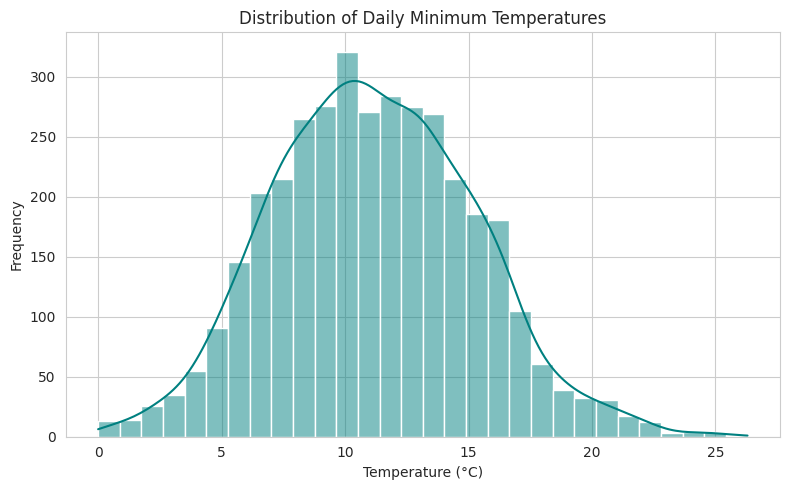

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
sns.histplot(df["Temp"], kde=True, color="teal", bins=30, ax=axes)
axes.set_title("Distribution of Daily Minimum Temperatures")
axes.set_xlabel("Temperature (°C)")
axes.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


### 3.2 Boxplot — Outlier Detection


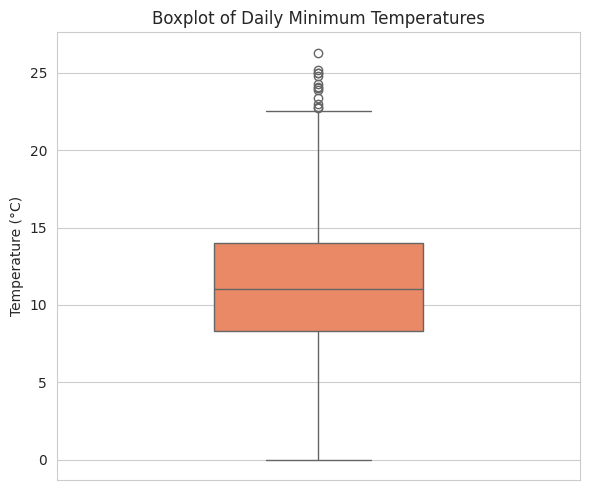

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
sns.boxplot(y=df["Temp"], color="coral", width=0.4, ax=axes)
axes.set_title("Boxplot of Daily Minimum Temperatures")
axes.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


### 3.3 Time Series Plot — Trend & Seasonality (Temperature)


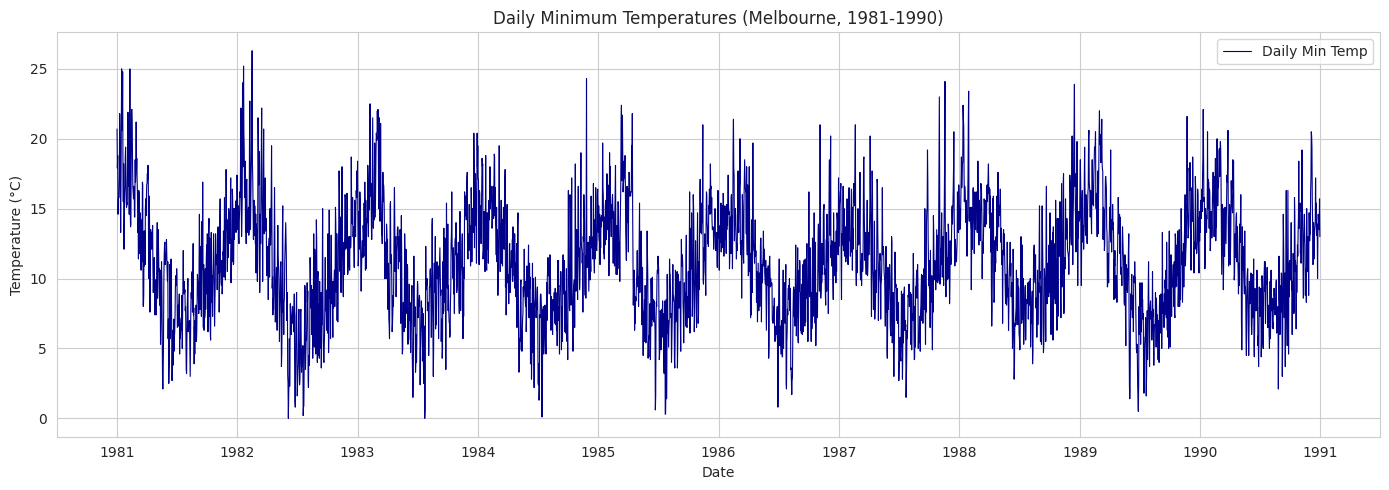

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Temp"], color="darkblue", linewidth=0.8, label="Daily Min Temp")
plt.title("Daily Minimum Temperatures (Melbourne, 1981-1990)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Time Series Analysis (Step 2)
### 4.1 Trend & Seasonal Decomposition


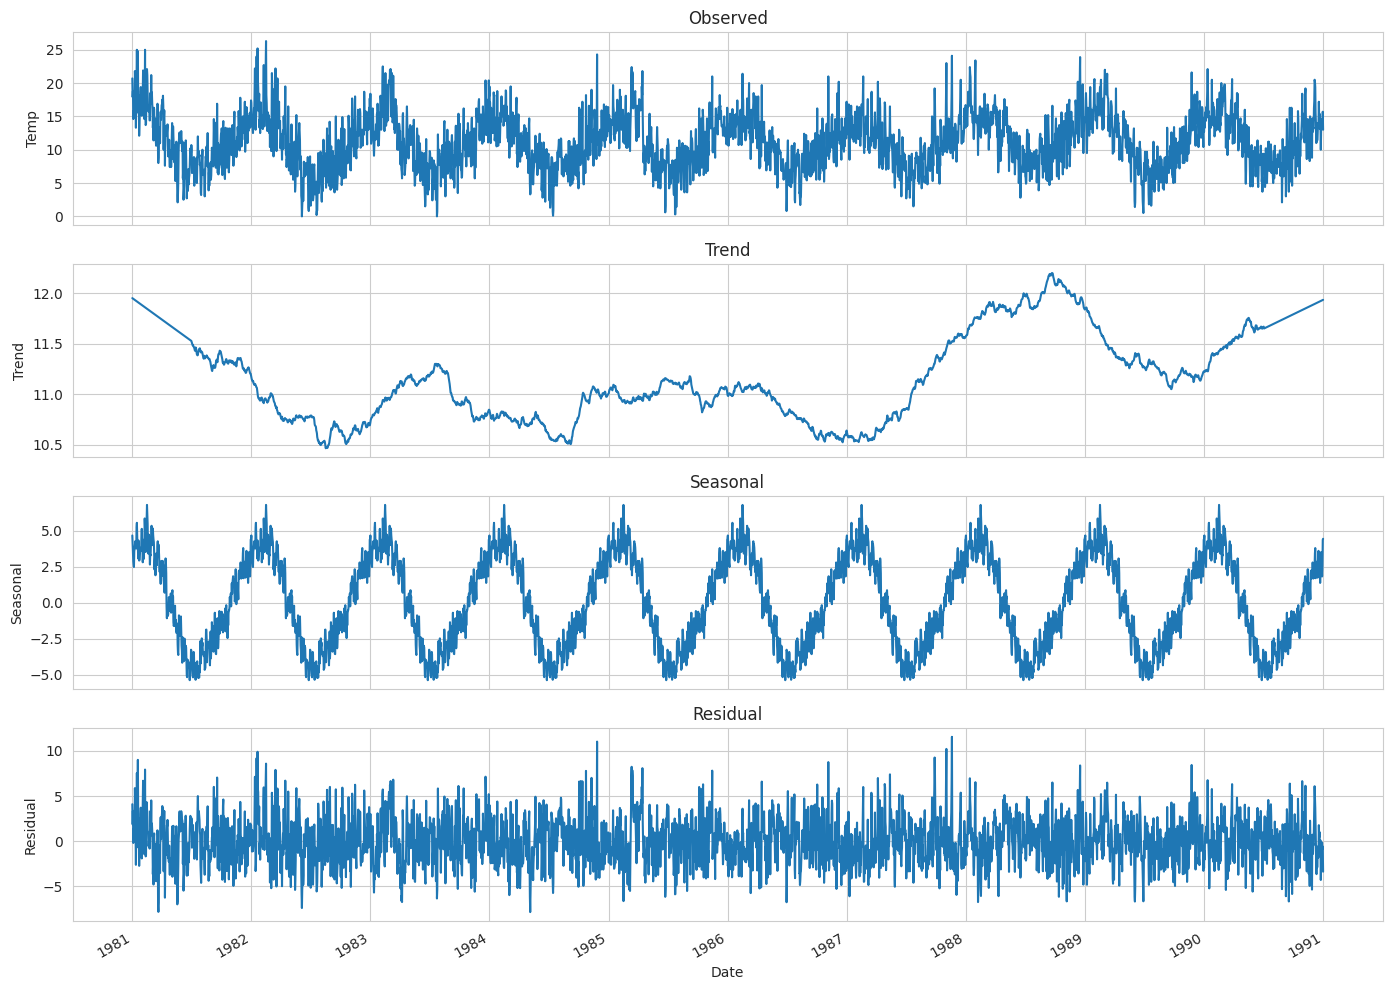

In [13]:
period = 365
decomposition = seasonal_decompose(df["Temp"], model="additive", period=period, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed"); axes[0].set_ylabel("Temp")
decomposition.trend.plot(ax=axes[1], title="Trend"); axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal"); axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual"); axes[3].set_ylabel("Residual")
plt.tight_layout()
plt.show()


### 4.2 Stationarity Analysis — Augmented Dickey-Fuller (ADF) Test


In [14]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test for: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")
    is_stat = result[1] <= 0.05
    print(f"Conclusion: {'Stationary' if is_stat else 'Non-Stationary'}\n")

adf_report(df["Temp"], "Temp")


--- ADF Test for: Temp ---
ADF Statistic: -4.4448
p-value: 2.4708e-04
Critical Values:
   1%: -3.4322
   5%: -2.8623
   10%: -2.5672
Conclusion: Stationary



### 4.3 Autocorrelation Analysis — ACF / PACF


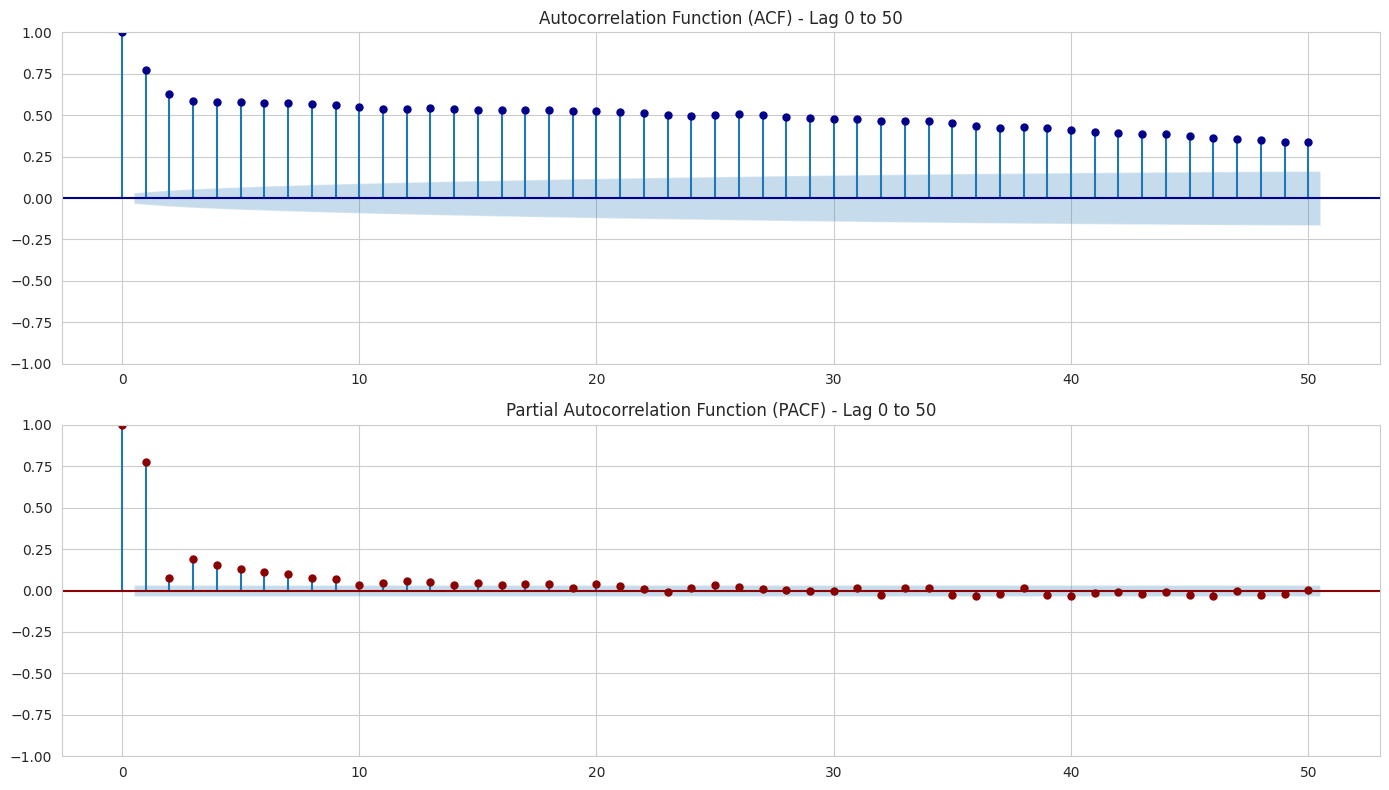

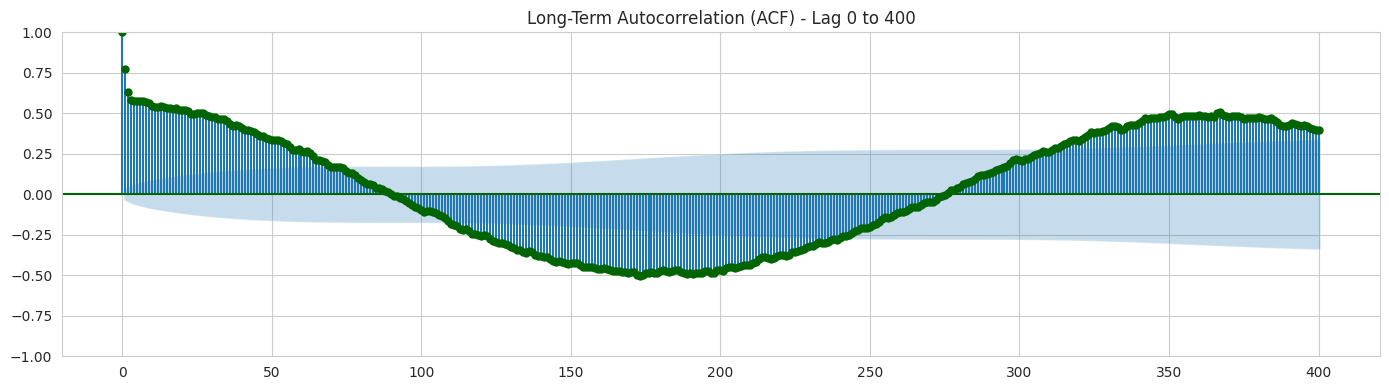

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df["Temp"], lags=50, ax=axes[0], color="darkblue")
axes[0].set_title("Autocorrelation Function (ACF) - Lag 0 to 50")
plot_pacf(df["Temp"], lags=50, ax=axes[1], color="darkred", method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF) - Lag 0 to 50")
plt.tight_layout()
plt.show()

# Long term seasonality ACF
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(df["Temp"], lags=400, ax=ax, color="darkgreen")
ax.set_title("Long-Term Autocorrelation (ACF) - Lag 0 to 400")
plt.tight_layout()
plt.show()


## 5. Data Preprocessing (Step 3)


In [16]:
# 5.1 Missing values
df_clean = df.copy()
df_clean = df_clean.ffill()
df_clean = df_clean.interpolate(method="linear")
print("Remaining NaNs:", df_clean.isna().sum().sum())


Remaining NaNs: 0


In [17]:
# 5.2 Chronological 80/20 split (index-based, shared by ALL models)
N = len(df_clean)
split_idx = int(N * (1 - TEST_RATIO))
print(f"Total obs: {N} | Train: {split_idx} | Test: {N - split_idx}")

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]
print("Train range:", train_df.index.min(), "->", train_df.index.max())
print("Test range :", test_df.index.min(), "->", test_df.index.max())


Total obs: 3650 | Train: 2920 | Test: 730
Train range: 1981-01-01 00:00:00 -> 1988-12-30 00:00:00
Test range : 1989-01-01 00:00:00 -> 1990-12-31 00:00:00


In [18]:
# 5.3 Scaling (fit on TRAIN ONLY to avoid leakage) - for ML/DL inputs
scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])

scaled_all = pd.DataFrame(
    scaler.transform(df_clean[FEATURES]),
    columns=FEATURES, index=df_clean.index
)
target_idx_in_features = FEATURES.index(TARGET)


In [19]:
# 5.4 Sliding window dataset builder (w = 30) for ML/DL models
def build_windows(scaled_df, window=WINDOW, target_col=TARGET, feature_cols=FEATURES):
    values = scaled_df[feature_cols].values
    target_pos = feature_cols.index(target_col)
    X, y, idx = [], [], []
    for t in range(window, len(values)):
        X.append(values[t-window:t, :])          # shape (window, n_features)
        y.append(values[t, target_pos])           # scaled target at time t
        idx.append(scaled_df.index[t])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)

X_all, y_all, idx_all = build_windows(scaled_all)
print("X_all shape:", X_all.shape, "| y_all shape:", y_all.shape)

# Align with the SAME chronological split_idx used above.
# Sample at original time index t belongs to test set if t >= split_idx.
window_split_idx = split_idx - WINDOW   # offset because first WINDOW points have no sample

X_train, y_train = X_all[:window_split_idx], y_all[:window_split_idx]
X_test,  y_test_scaled  = X_all[window_split_idx:], y_all[window_split_idx:]
idx_test = idx_all[window_split_idx:]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Test target timestamps:", idx_test.min(), "->", idx_test.max())
assert len(idx_test) == (N - split_idx), "Test alignment mismatch!"


X_all shape: (3620, 30, 1) | y_all shape: (3620,)
X_train: (2890, 30, 1) X_test: (730, 30, 1)
Test target timestamps: 1989-01-01 00:00:00 -> 1990-12-31 00:00:00


In [20]:
# True (unscaled) test targets — the ground truth used for ALL models' evaluation
y_test_true = test_df[TARGET].values
print("y_test_true shape:", y_test_true.shape)


y_test_true shape: (730,)


In [21]:
# Helper to inverse-transform a scaled Close prediction back to price units
def inverse_close(scaled_preds):
    dummy = np.zeros((len(scaled_preds), len(FEATURES)))
    dummy[:, target_idx_in_features] = scaled_preds
    unscaled = scaler.inverse_transform(dummy)
    return unscaled[:, target_idx_in_features]


## 6. Evaluation Metric Helper (MAE, RMSE, MAPE, R²)


In [22]:
results = []
errors_by_model = {}
preds_by_model = {}

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"[{model_name}] MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.4f}% | R2: {r2:.4f}")
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }


## 7. Model 1 — Holt-Winters Exponential Smoothing (Step 4)


In [23]:
import time
t0 = time.time()

hw_preds = []
history = list(train_df[TARGET].values)

for t in range(len(idx_test)):
    try:
        # trend='add', seasonal=None to keep walk-forward fast & prevent convergence failure
        model_hw = ExponentialSmoothing(
            pd.Series(history), trend="add", seasonal=None, initialization_method="estimated"
        ).fit()
        pred = model_hw.forecast(1).values[0]
    except Exception:
        pred = history[-1]  # fallback: naive persistence
    hw_preds.append(pred)
    history.append(y_test_true[t])  # walk-forward update

hw_time = time.time() - t0
hw_preds = np.array(hw_preds)
print(f"Holt-Winters walk-forward training time: {hw_time:.2f}s")

res = evaluate(y_test_true, hw_preds, "Holt-Winters")
res["TrainTime_s"] = hw_time
res["InferTime_s"] = hw_time / len(idx_test)
results.append(res)
errors_by_model["Holt-Winters"] = np.abs(y_test_true - hw_preds)
preds_by_model["Holt-Winters"] = hw_preds


Holt-Winters walk-forward training time: 158.00s
[Holt-Winters] MAE: 1.8874 | RMSE: 2.4111 | MAPE: 21.6685% | R2: 0.6548


## 8. Model 2 — ARIMA (Step 5)


In [24]:
from itertools import product

def select_arima_order(train_series, p_range=range(0,3), d=1, q_range=range(0,3)):
    best_aic, best_order = np.inf, (1,1,1)
    for p, q in product(p_range, q_range):
        try:
            m = ARIMA(train_series, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d, q)
        except Exception:
            continue
    return best_order, best_aic

best_order, best_aic = select_arima_order(train_df[TARGET])
print("Selected ARIMA order:", best_order, "AIC:", round(best_aic, 2))


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Selected ARIMA order: (2, 1, 1) AIC: 13539.15


In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

t0 = time.time()

model = SARIMAX(
    train_df[TARGET],
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima = model.fit(disp=False)
arima_preds_list = []

for y in y_test_true:
    pred = results_arima.forecast(1).iloc[0]
    arima_preds_list.append(pred)
    # Append new true observation and update state without refitting
    results_arima = results_arima.append([y], refit=False)

arima_preds = np.asarray(arima_preds_list)
arima_time = time.time() - t0
print(f"ARIMA walk-forward time: {arima_time:.2f}s")

res = evaluate(y_test_true, arima_preds, "ARIMA")
res["TrainTime_s"] = arima_time
res["InferTime_s"] = arima_time / len(idx_test)
results.append(res)
errors_by_model["ARIMA"] = np.abs(y_test_true - arima_preds)
preds_by_model["ARIMA"] = arima_preds


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-p

ARIMA walk-forward time: 22.10s
[ARIMA] MAE: 1.7383 | RMSE: 2.2100 | MAPE: 20.6427% | R2: 0.7100


## 9. Model 3 — XGBoost (Step 6)


In [26]:
# Flatten window for XGBoost: (n_samples, window*n_features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=SEED
)
xgb_model.fit(X_train_flat, y_train)
xgb_train_time = time.time() - t0

t0 = time.time()
xgb_pred_scaled = xgb_model.predict(X_test_flat)
xgb_infer_time = time.time() - t0

xgb_preds = inverse_close(xgb_pred_scaled)
print(f"XGBoost train time: {xgb_train_time:.2f}s | inference time: {xgb_infer_time:.4f}s")

res = evaluate(y_test_true, xgb_preds, "XGBoost")
res["TrainTime_s"] = xgb_train_time
res["InferTime_s"] = xgb_infer_time
results.append(res)
errors_by_model["XGBoost"] = np.abs(y_test_true - xgb_preds)
preds_by_model["XGBoost"] = xgb_preds


XGBoost train time: 1.86s | inference time: 0.0089s
[XGBoost] MAE: 1.7901 | RMSE: 2.2531 | MAPE: 20.6672% | R2: 0.6986


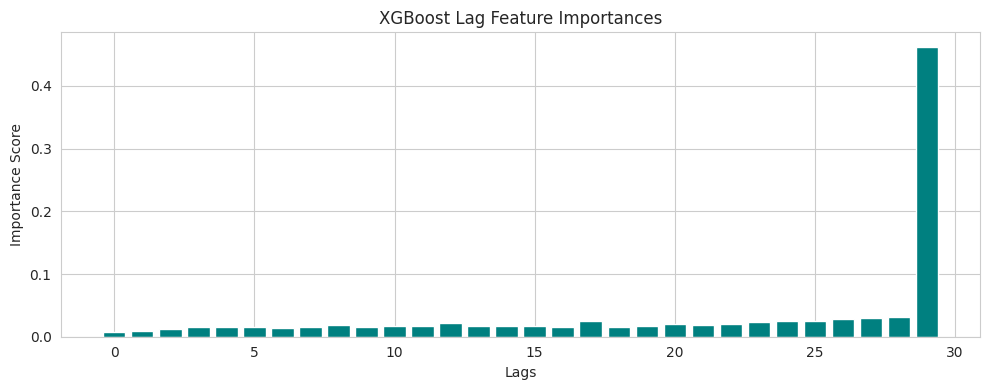

In [27]:
# Feature importance plot
importances = xgb_model.feature_importances_
plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances, color="teal")
plt.title("XGBoost Lag Feature Importances")
plt.xlabel("Lags")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


## 10. Model 4 — LSTM (Step 7)


In [28]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

n_features = X_train.shape[2]

lstm_model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=0
)
lstm_train_time = time.time() - t0
print(f"LSTM train time: {lstm_train_time:.2f}s | epochs run: {len(history_lstm.history['loss'])}")


LSTM train time: 76.14s | epochs run: 31


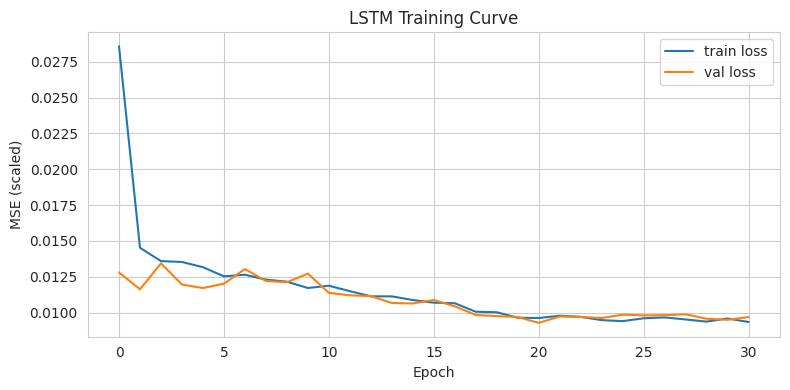

In [30]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()


In [31]:
t0 = time.time()
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
lstm_infer_time = time.time() - t0

lstm_preds = inverse_close(lstm_pred_scaled)
res = evaluate(y_test_true, lstm_preds, "LSTM")
res["TrainTime_s"] = lstm_train_time
res["InferTime_s"] = lstm_infer_time
results.append(res)
errors_by_model["LSTM"] = np.abs(y_test_true - lstm_preds)
preds_by_model["LSTM"] = lstm_preds
print(f"Inference time: {lstm_infer_time:.4f}s")


[LSTM] MAE: 1.8366 | RMSE: 2.3307 | MAPE: 21.6825% | R2: 0.6774
Inference time: 0.7605s


## 11. Model 5 — Transformer (Step 8)


In [32]:
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)
    res = x
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + res)
    return x

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

inputs = layers.Input(shape=(WINDOW, n_features))
x = transformer_encoder(inputs)
x = transformer_encoder(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)

transformer_model = models.Model(inputs, outputs)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │      1,793 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 1)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 1)     │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 1)     │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │      1,793 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 1)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 1)     │        129 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 1)     │          0 │ dense_3[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,461 (17.43 KB)

 Trainable params: 4,461 (17.43 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop_tr = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_tr = transformer_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop_tr], verbose=0
)
tr_train_time = time.time() - t0
print(f"Transformer train time: {tr_train_time:.2f}s | epochs run: {len(history_tr.history['loss'])}")


Transformer train time: 378.76s | epochs run: 98


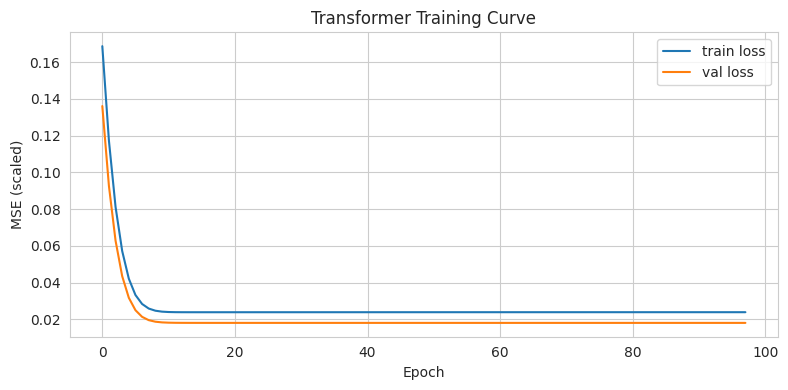

In [34]:
plt.figure(figsize=(8,4))
plt.plot(history_tr.history["loss"], label="train loss")
plt.plot(history_tr.history["val_loss"], label="val loss")
plt.title("Transformer Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()


In [35]:
t0 = time.time()
tr_pred_scaled = transformer_model.predict(X_test, verbose=0).flatten()
tr_infer_time = time.time() - t0

tr_preds = inverse_close(tr_pred_scaled)
res = evaluate(y_test_true, tr_preds, "Transformer")
res["TrainTime_s"] = tr_train_time
res["InferTime_s"] = tr_infer_time
results.append(res)
errors_by_model["Transformer"] = np.abs(y_test_true - tr_preds)
preds_by_model["Transformer"] = tr_preds
print(f"Inference time: {tr_infer_time:.4f}s")


[Transformer] MAE: 3.4004 | RMSE: 4.1241 | MAPE: 42.5048% | R2: -0.0099
Inference time: 0.8789s


## 12. Performance Comparison Table (Step 9 & 10)


In [36]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df[["MAE", "RMSE", "MAPE (%)", "R2", "TrainTime_s", "InferTime_s"]]
results_df.to_csv("melbourne_model_comparison_results.csv")
print("Saved: melbourne_model_comparison_results.csv")
results_df


Saved: melbourne_model_comparison_results.csv


,MAE,RMSE,MAPE (%),R2,TrainTime_s,InferTime_s
Model,,,,,,
Holt-Winters,1.887427,2.411056,21.668473,0.654822,157.995596,0.216432
ARIMA,1.738275,2.210049,20.642730,0.709977,22.099899,0.030274
XGBoost,1.790144,2.253147,20.667222,0.698556,1.859654,0.008921
LSTM,1.836594,2.330742,21.682488,0.677436,76.135252,0.760489
Transformer,3.400442,4.124122,42.504793,-0.009930,378.757963,0.878869


In [37]:
print("\nResults Markdown Table:")
print("| Model | MAE | RMSE | MAPE (%) | R2 | Train Time (s) | Inference Time (s) |")
print("| :--- | :--- | :--- | :--- | :--- | :--- | :--- |")
for idx, r in results_df.iterrows():
    print(f"| {idx} | {r['MAE']:.4f} | {r['RMSE']:.4f} | {r['MAPE (%)']:.4f} | {r['R2']:.4f} | {r['TrainTime_s']:.4f} | {r['InferTime_s']:.4f} |")



Results Markdown Table:
| Model | MAE | RMSE | MAPE (%) | R2 | Train Time (s) | Inference Time (s) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Holt-Winters | 1.8874 | 2.4111 | 21.6685 | 0.6548 | 157.9956 | 0.2164 |
| ARIMA | 1.7383 | 2.2100 | 20.6427 | 0.7100 | 22.0999 | 0.0303 |
| XGBoost | 1.7901 | 2.2531 | 20.6672 | 0.6986 | 1.8597 | 0.0089 |
| LSTM | 1.8366 | 2.3307 | 21.6825 | 0.6774 | 76.1353 | 0.7605 |
| Transformer | 3.4004 | 4.1241 | 42.5048 | -0.0099 | 378.7580 | 0.8789 |


## 13. Visualization of Results


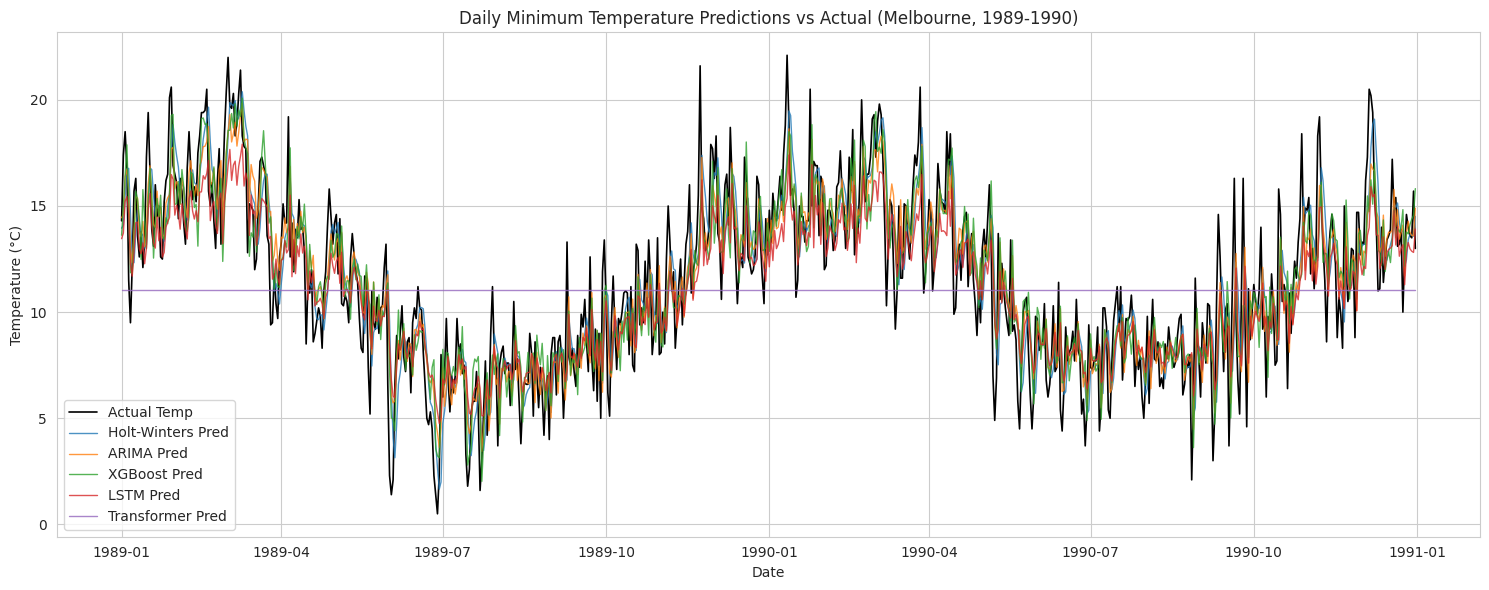

In [38]:
# 13.1 Predicted vs Actual — all models overlay
plt.figure(figsize=(15, 6))
plt.plot(idx_test, y_test_true, label="Actual Temp", color="black", linewidth=1.2)
for model_name, preds in preds_by_model.items():
    plt.plot(idx_test, preds, label=f"{model_name} Pred", alpha=0.8, linewidth=1.0)
plt.title("Daily Minimum Temperature Predictions vs Actual (Melbourne, 1989-1990)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()


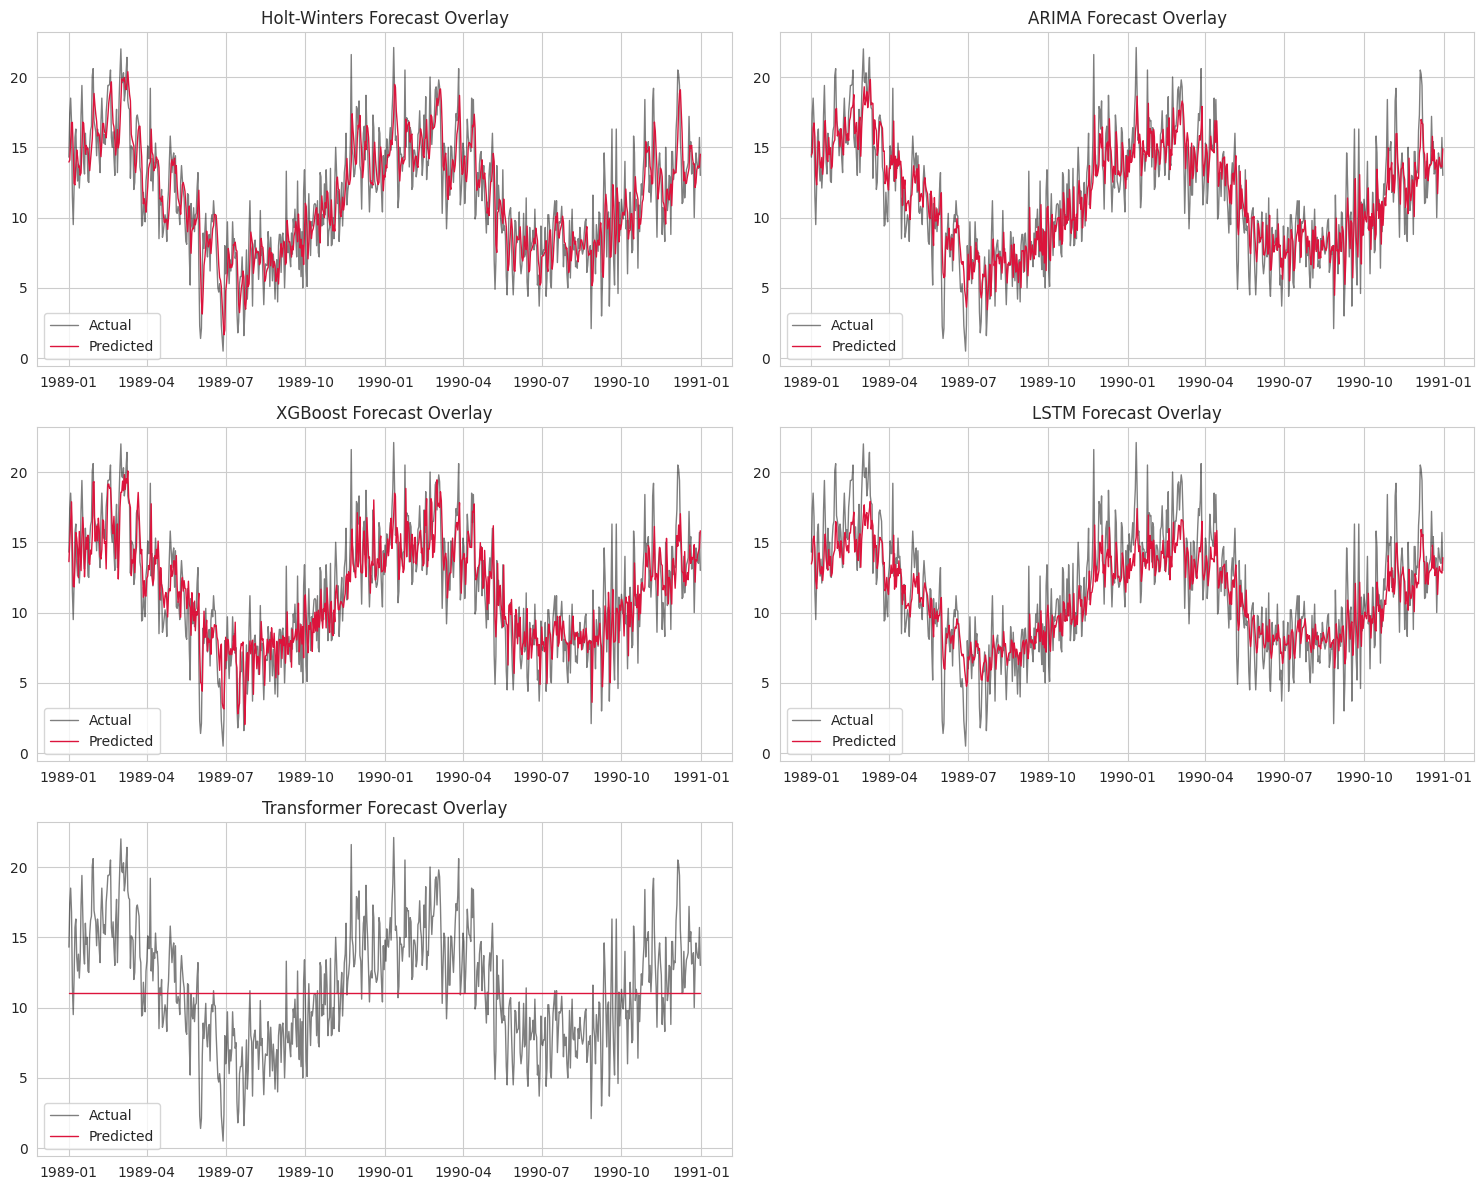

In [39]:
# 13.2 Individual subplots per model
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes_flat = axes.flatten()
for idx, (model_name, preds) in enumerate(preds_by_model.items()):
    ax = axes_flat[idx]
    ax.plot(idx_test, y_test_true, label="Actual", color="black", alpha=0.5, linewidth=1.0)
    ax.plot(idx_test, preds, label="Predicted", color="crimson", linewidth=1.0)
    ax.set_title(f"{model_name} Forecast Overlay")
    ax.legend()
# Hide the empty 6th subplot
axes_flat[-1].axis('off')
plt.tight_layout()
plt.show()


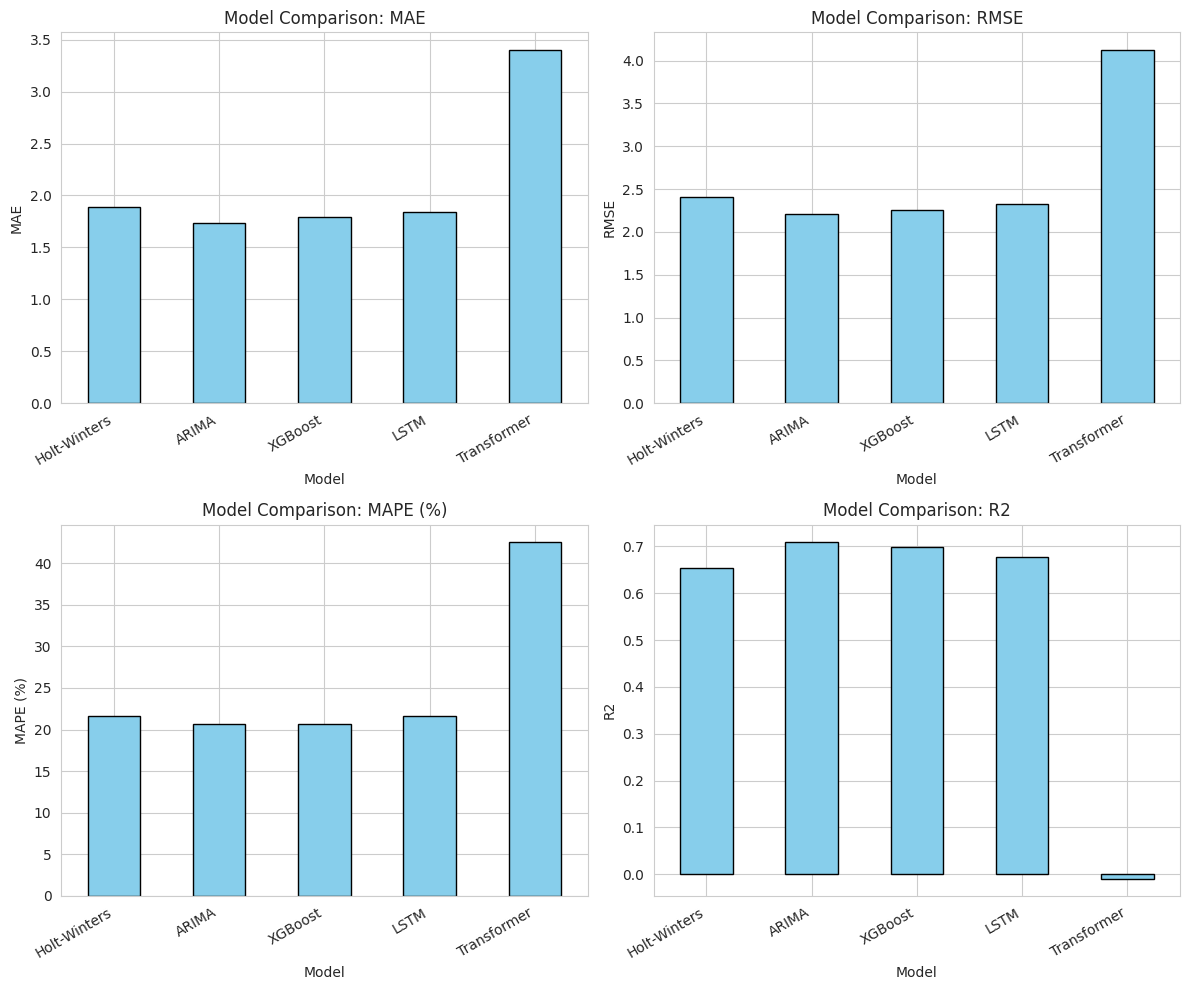

In [40]:
# 13.3 Metric comparison bar charts
metrics_to_plot = ["MAE", "RMSE", "MAPE (%)", "R2"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    results_df[metric].plot(kind="bar", ax=ax, color="skyblue", edgecolor="black")
    ax.set_title(f"Model Comparison: {metric}")
    ax.set_ylabel(metric)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()


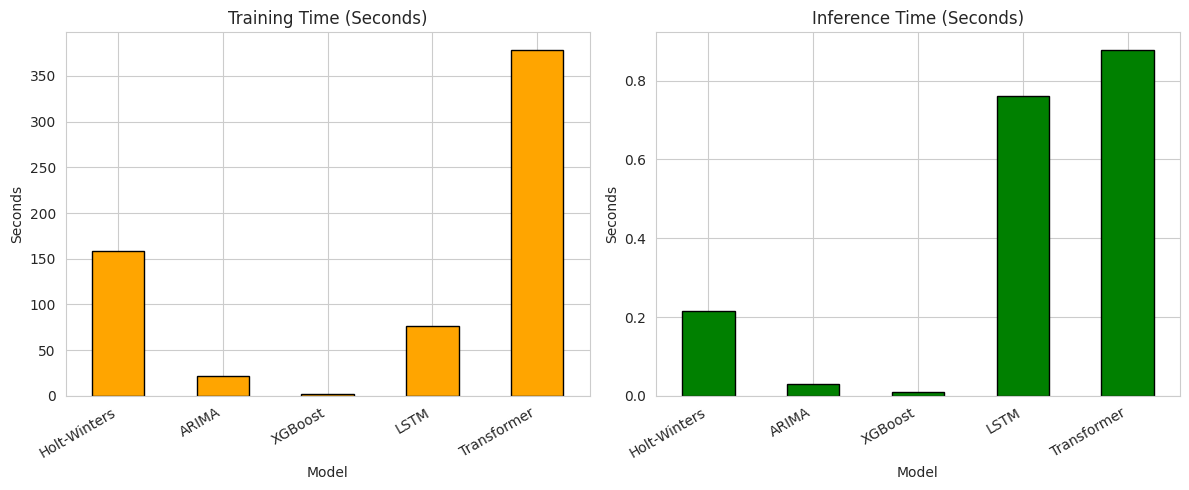

In [41]:
# 13.4 Training vs Inference time
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
results_df["TrainTime_s"].plot(kind="bar", ax=axes[0], color="orange", edgecolor="black")
axes[0].set_title("Training Time (Seconds)")
axes[0].set_ylabel("Seconds")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

results_df["InferTime_s"].plot(kind="bar", ax=axes[1], color="green", edgecolor="black")
axes[1].set_title("Inference Time (Seconds)")
axes[1].set_ylabel("Seconds")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


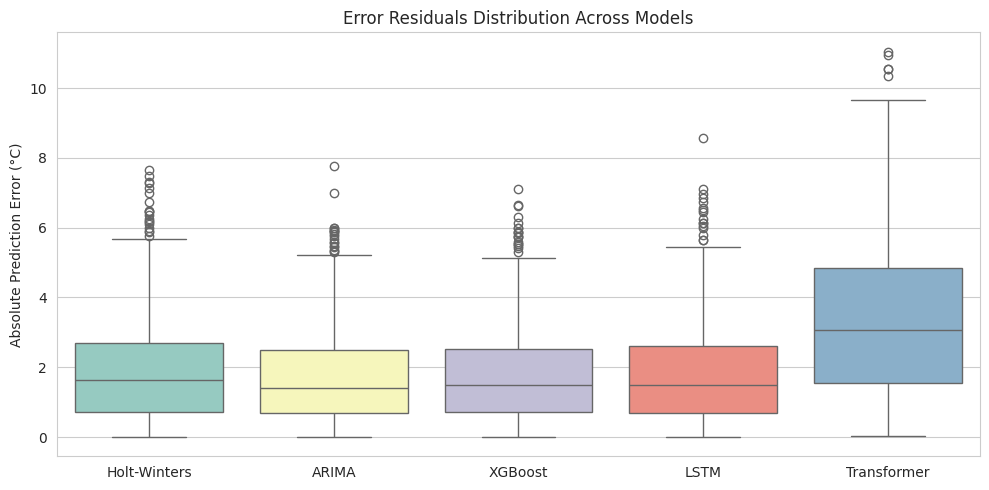

In [42]:
# 13.5 Error distribution boxplot (per-timestamp absolute errors)
err_df = pd.DataFrame(errors_by_model)
plt.figure(figsize=(10, 5))
sns.boxplot(data=err_df, palette="Set3")
plt.title("Error Residuals Distribution Across Models")
plt.ylabel("Absolute Prediction Error (°C)")
plt.tight_layout()
plt.show()


## 14. Statistical Comparison of Results (Step 12)


In [43]:
from itertools import combinations
from scipy.stats import wilcoxon, shapiro

model_names = list(errors_by_model.keys())
comparison_rows = []

for m1, m2 in combinations(model_names, 2):
    e1, e2 = errors_by_model[m1], errors_by_model[m2]
    diff = e1 - e2

    # Normality check on the differences (Shapiro-Wilk)
    try:
        _, p_norm = shapiro(diff)
    except Exception:
        p_norm = np.nan
    normal = p_norm > 0.05 if not np.isnan(p_norm) else False

    # Relational t-test
    _, p_t = stats.ttest_rel(e1, e2)
    try:
        w_stat, p_w = wilcoxon(e1, e2)
    except Exception:
        w_stat, p_w = np.nan, np.nan

    comparison_rows.append({
        "Model A": m1, "Model B": m2,
        "Shapiro p (normality of diff)": round(p_norm, 4) if not np.isnan(p_norm) else np.nan,
        "Paired t-test p-value": round(p_t, 4),
        "Significant (t-test, a=0.05)": p_t < 0.05,
        "Wilcoxon p-value": round(p_w, 4) if not np.isnan(p_w) else np.nan,
        "Significant (Wilcoxon, a=0.05)": (p_w < 0.05) if not np.isnan(p_w) else np.nan,
        "Recommended test": "t-test" if normal else "Wilcoxon"
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("melbourne_statistical_comparison.csv", index=False)
print("Saved: melbourne_statistical_comparison.csv")
comparison_df


Saved: melbourne_statistical_comparison.csv


,Model A,Model B,Shapiro p (normality of diff),Paired t-test p-value,"Significant (t-test, a=0.05)",Wilcoxon p-value,"Significant (Wilcoxon, a=0.05)",Recommended test
0,Holt-Winters,ARIMA,0.0084,0.0000,True,0.0000,True,Wilcoxon
1,Holt-Winters,XGBoost,0.0216,0.0088,True,0.0153,True,Wilcoxon
2,Holt-Winters,LSTM,0.0000,0.1714,False,0.1108,False,Wilcoxon
3,Holt-Winters,Transformer,0.1472,0.0000,True,0.0000,True,t-test
4,ARIMA,XGBoost,0.0382,0.0629,False,0.0453,True,Wilcoxon
5,ARIMA,LSTM,0.0000,0.0004,True,0.0005,True,Wilcoxon
6,ARIMA,Transformer,0.1076,0.0000,True,0.0000,True,t-test
7,XGBoost,LSTM,0.0002,0.1784,False,0.3230,False,Wilcoxon
8,XGBoost,Transformer,0.0006,0.0000,True,0.0000,True,Wilcoxon
9,LSTM,Transformer,0.0174,0.0000,True,0.0000,True,Wilcoxon


In [44]:
p_value_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)
np.fill_diagonal(p_value_matrix.values, 1.0)

for row in comparison_rows:
    m_a, m_b = row["Model A"], row["Model B"]
    p_val = row["Wilcoxon p-value"] if row["Recommended test"] == "Wilcoxon" else row["Paired t-test p-value"]
    p_value_matrix.loc[m_a, m_b] = p_val
    p_value_matrix.loc[m_b, m_a] = p_val

print("\np-Value Matrix (Hypothesis testing results):")
print(p_value_matrix.to_string())

print("\nMarkdown Table for p-Value Matrix:")
header = "| | " + " | ".join(model_names) + " |"
separator = "| :--- | " + " | ".join([":---" for _ in model_names]) + " |"
print(header)
print(separator)
for m_row in model_names:
    row_values = []
    for m_col in model_names:
        val = p_value_matrix.loc[m_row, m_col]
        row_values.append(f"{val:.4e}" if not pd.isna(val) else "1.0000e+00")
    print(f"| {m_row} | " + " | ".join(row_values) + " |")



p-Value Matrix (Hypothesis testing results):
              Holt-Winters   ARIMA  XGBoost    LSTM  Transformer
Holt-Winters        1.0000  0.0000   0.0153  0.1108          0.0
ARIMA               0.0000  1.0000   0.0453  0.0005          0.0
XGBoost             0.0153  0.0453   1.0000  0.3230          0.0
LSTM                0.1108  0.0005   0.3230  1.0000          0.0
Transformer         0.0000  0.0000   0.0000  0.0000          1.0

Markdown Table for p-Value Matrix:
| | Holt-Winters | ARIMA | XGBoost | LSTM | Transformer |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Holt-Winters | 1.0000e+00 | 0.0000e+00 | 1.5300e-02 | 1.1080e-01 | 0.0000e+00 |
| ARIMA | 0.0000e+00 | 1.0000e+00 | 4.5300e-02 | 5.0000e-04 | 0.0000e+00 |
| XGBoost | 1.5300e-02 | 4.5300e-02 | 1.0000e+00 | 3.2300e-01 | 0.0000e+00 |
| LSTM | 1.1080e-01 | 5.0000e-04 | 3.2300e-01 | 1.0000e+00 | 0.0000e+00 |
| Transformer | 0.0000e+00 | 0.0000e+00 | 0.0000e+00 | 0.0000e+00 | 1.0000e+00 |
